# 04 — EDA, Modelling & Export (aligned to Research Questions)

This notebook is the final, human‑readable handover that assembles analysis and export artifacts question‑by‑question (graphs, tables, and a brief narrative answer for each RQ).

Problem Statement
Tipping behavior in ridesharing and taxi services is influenced by multiple trip factors such as distance, duration, timing, passenger count, and payment method. These factors interact with economic and behavioral patterns. This analysis seeks to understand how measurable trip characteristics influence tip amounts and tipping percentages. By identifying which factors predict tipping behavior the most, the analysis aims to support data‑driven strategies that improve driver earnings and enhance customer experience.

Research Questions
1. Trip Spatial and Time Patterns
   - How does trip distance, duration, pick‑up and drop‑off points relate to the absolute tip amount and tip percentage?
2. Temporal Factors
   - How does the time of day, day of the week and seasonality influence tipping amounts and percentages?
3. Passenger and Fare Characteristics
   - How do fare components (base fare, surcharges, tolls or airport fees) impact the tip amount?

What you’ll find below
- RQ1: Trip spatial/time patterns vs tip amount and tip percent
- RQ2: Temporal factors (hour, day, season) and weather vs tipping
- RQ3: Fare components vs tip amount/percent (controlled comparisons)

Outputs (saved under `docs/figures/` and `docs/tables/`): aggregated tables, plots, and concise report‑ready blocks. All steps are aggregation‑first to be fast and reproducible on large data.

In [23]:
# Imports, config, and data load
import os
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
TAB_DIR = PROJECT_ROOT / "docs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

# Authoritative parquet from Notebook 02
DATA_FILE = Path(r"X:\\data\\processed\\nyc_2024_trips_weather_preprocessed.parquet")
if not DATA_FILE.exists():
    # Fallback to local copy if X: is unavailable
    DATA_FILE = PROJECT_ROOT / "data" / "processed" / "nyc_2024_trips_weather_preprocessed.parquet"

print("Loading:", DATA_FILE)
df = pd.read_parquet(DATA_FILE)
print("Shape:", df.shape)
print("Columns (first 10):", list(df.columns[:10]))


Loading: X:\data\processed\nyc_2024_trips_weather_preprocessed.parquet
Shape: (41128509, 37)
Columns (first 10): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge']
Shape: (41128509, 37)
Columns (first 10): ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge']


In [24]:
# Final readiness checks (nulls, dtypes, quick head)
nulls_total = int(df.isna().sum().sum())
print("Total missing values:", f"{nulls_total:,}")
print("\nDtypes summary (first 20):\n", df.dtypes.head(20))
df.head(3)

Total missing values: 0

Dtypes summary (first 20):
 tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
PULocationID                      int32
DOLocationID                      int32
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tolls_amount                    float64
improvement_surcharge           float64
congestion_surcharge            float64
airport_fee                     float64
tip_amount                      float64
total_amount                    float64
trip_duration_min               float64
other_charges                   float64
pickup_hour_local        datetime64[us]
temp_c                          float64
rh_percent                      float64
wind_ms                         float64
dtype: object


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,extra,mta_tax,tolls_amount,improvement_surcharge,...,paytype_3,paytype_4,paytype_5,tip_percent_raw,tip_percent_z,duration_min,pickup_hour,dow,month,season
0,2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,-0.394250,0.020871,1.0,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,19.800000,0,0,1,Winter
1,2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,-0.356150,-0.652259,3.5,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,6.600000,0,0,1,Winter
2,2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1.024977,0.510420,3.5,0.5,0.0,1.0,...,False,False,False,0.0,-1.071352,17.916667,0,0,1,Winter


### RQ1 — Trip spatial & time patterns → tip amount and tip percent

We summarize how trip distance and duration relate to tipping. We bin the variables to stabilize estimates, then compute medians (robust to skew) and counts for reliability. Spatial effects are shown via top/bottom pickup and drop-off IDs by median tip percent.

Outputs: `rq1_bins_summary.csv`, `rq1_heatmap_tip_percent.png`, and top/bottom PU/DO tables under `docs/tables/`.

C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\2664233644.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metrics = df.groupby(agg_cols).agg(


Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\tables\rq1_bins_summary.csv


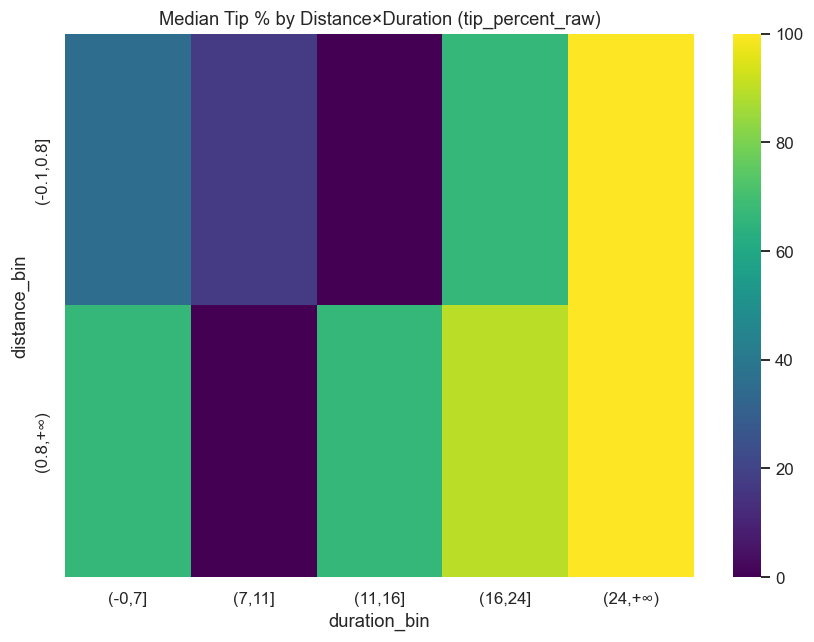

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq1_heatmap_tip_percent.png
Saved top/bottom tables for PULocationID
Saved top/bottom tables for PULocationID
Saved top/bottom tables for DOLocationID
Saved top/bottom tables for DOLocationID


In [25]:
# RQ1 bins, aggregations, and heatmap

# Ensure required columns
essential = ["trip_distance", "tip_amount", "tip_percent_raw"]
missing = [c for c in essential if c not in df.columns]
if missing:
    print("[RQ1] Missing columns:", missing)

# Duration may be missing in some builds; handle gracefully
has_duration = "duration_min" in df.columns

# Distance bins (quantiles with domain caps)
q = df["trip_distance"].clip(lower=0).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
q = np.unique(q)  # protect against duplicates
if len(q) < 3:
    # fallback fixed bins
    dist_bins = [-0.1, 1, 3, 7, 15, np.inf]
else:
    dist_bins = [-0.1] + list(q[1:-1]) + [np.inf]

labels_dist = [f"({dist_bins[i]:.1f},{dist_bins[i+1]:.1f}]" if i < len(dist_bins)-2 else f"({dist_bins[i]:.1f},+∞)" for i in range(len(dist_bins)-1)]
df["distance_bin"] = pd.cut(df["trip_distance"].clip(lower=0), bins=dist_bins, labels=labels_dist)

# Duration bins if available
if has_duration:
    d = df["duration_min"].clip(lower=0).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
    d = np.unique(d)
    if len(d) < 3:
        dur_bins = [-0.1, 5, 10, 20, 40, np.inf]
    else:
        dur_bins = [-0.1] + list(d[1:-1]) + [np.inf]
    labels_dur = [f"({dur_bins[i]:.0f},{dur_bins[i+1]:.0f}]" if i < len(dur_bins)-2 else f"({dur_bins[i]:.0f},+∞)" for i in range(len(dur_bins)-1)]
    df["duration_bin"] = pd.cut(df["duration_min"].clip(lower=0), bins=dur_bins, labels=labels_dur)

# Aggregations
agg_cols = ["distance_bin"] + (["duration_bin"] if has_duration else [])
metrics = df.groupby(agg_cols).agg(
    n=("tip_amount", "size"),
    med_tip_amt=("tip_amount", "median"),
    med_tip_pct=("tip_percent_raw", "median"),
).reset_index()

# Save table
out_tbl = TAB_DIR / "rq1_bins_summary.csv"
metrics.to_csv(out_tbl, index=False)
print("Saved:", out_tbl)

# Heatmap of median tip % by distance x duration (if duration exists)
if has_duration:
    pivot = metrics.pivot(index="distance_bin", columns="duration_bin", values="med_tip_pct")
    plt.figure(figsize=(8,6))
    sns.heatmap(pivot, annot=False, cmap="viridis")
    plt.title("Median Tip % by Distance×Duration (tip_percent_raw)")
    fig_path = FIG_DIR / "rq1_heatmap_tip_percent.png"
    plt.tight_layout()
    plt.savefig(fig_path)
    plt.show()
    print("Saved:", fig_path)

# Spatial: top/bottom PU/DO by median tip % (IDs)
for loc_col in [c for c in ["PULocationID", "DOLocationID"] if c in df.columns]:
    t = df.groupby(loc_col).agg(n=("tip_percent_raw", "size"), med_tip_pct=("tip_percent_raw", "median")).reset_index()
    t = t.sort_values("med_tip_pct", ascending=False)
    top10 = t.head(10)
    bot10 = t.tail(10)
    top10.to_csv(TAB_DIR / f"rq1_{loc_col}_top10_tip_pct.csv", index=False)
    bot10.to_csv(TAB_DIR / f"rq1_{loc_col}_bottom10_tip_pct.csv", index=False)
    print(f"Saved top/bottom tables for {loc_col}")


## Q1. Trip spatial and time patterns -> How do trip distance, duration, and pickup/drop‑off locations relate to tip amount and tip percentage?

- The heatmap above shows a clear gradient: longer and/or slower trips tend to receive higher median tip percentages; shorter or mid‑length trips have lower medians.
- Several pickup and drop‑off zones consistently rank near the top or bottom by median tip %, suggesting location context matters (e.g., airports, nightlife, or commuter hubs).
- Read the tables with the counts (n) in mind—bins with more trips are more reliable.

Why this makes sense
- Longer time/distance generally implies more service time and perceived value, which supports higher tipping norms.
- Zones reflect rider mix and trip purposes (airport transfers, business districts, entertainment areas).

Caveats
- These are observational patterns, not causal effects.
- Tip amount fields may be standardized in this dataset; tip_percent_raw is the most interpretable measure.


### Report-ready — RQ1: Distance × Duration and spatial summary

The next cell produces an Executive Summary and Technical Notes, with small tables for copy‑paste.

In [26]:
# Compose RQ1 summary bullets and copy‑paste markdown + tables
from IPython.display import display, Markdown

# Ensure 'metrics' exists, else rebuild quickly
if 'metrics' not in globals() or not isinstance(metrics, pd.DataFrame) or metrics.empty:
    has_duration = 'duration_min' in df.columns
    # fallback simple bins
    dist_bins = [-0.1, 1, 3, 7, 15, float('inf')]
    df['distance_bin'] = pd.cut(df['trip_distance'].clip(lower=0), bins=dist_bins)
    if has_duration:
        dur_bins = [-0.1, 5, 10, 20, 40, float('inf')]
        df['duration_bin'] = pd.cut(df['duration_min'].clip(lower=0), bins=dur_bins)
    agg_cols = ['distance_bin'] + (['duration_bin'] if has_duration else [])
    metrics = df.groupby(agg_cols).agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index()

m = metrics.copy()
# Identify strongest and weakest bins by median tip %
row_max = m.loc[m['med_tip_pct'].idxmax()].to_dict()
row_min = m.loc[m['med_tip_pct'].idxmin()].to_dict()
span = row_max['med_tip_pct'] - row_min['med_tip_pct']

# Spatial top 5 (PU/DO)
pu = df.groupby('PULocationID').agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index().sort_values('med_tip_pct', ascending=False).head(5) if 'PULocationID' in df.columns else None
do = df.groupby('DOLocationID').agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index().sort_values('med_tip_pct', ascending=False).head(5) if 'DOLocationID' in df.columns else None

# Exec bullets
bin_label = lambda r: (
    f"distance {r.get('distance_bin','?')} × duration {r.get('duration_bin','(all)')}" if 'duration_bin' in m.columns else f"distance {r.get('distance_bin','?')}"
)
exec_bullets = [
    f"Highest median tip % is {row_max['med_tip_pct']:.1f}% in {bin_label(row_max)} (n={int(row_max['n']):,}).",
    f"Lowest median tip % is {row_min['med_tip_pct']:.1f}% in {bin_label(row_min)} (n={int(row_min['n']):,}).",
    f"Spread across bins is {span:.1f} percentage points (pp).",
]
if pu is not None:
    exec_bullets.append(f"Top pickup areas by median tip % include IDs {', '.join(map(str, pu['PULocationID'].tolist()))}.")
if do is not None:
    exec_bullets.append(f"Top drop-off areas by median tip % include IDs {', '.join(map(str, do['DOLocationID'].tolist()))}.")

# Technical notes
tech_notes = []
if 'dist_bins' in globals():
    tech_notes.append(f"Distance bins: {dist_bins} (edges).")
if 'dur_bins' in globals() or ('duration_bin' in df.columns):
    tech_notes.append(f"Duration bins present; medians computed per distance×duration cell.")
tech_notes += [
    "Medians used for robustness; counts (n) provided for reliability.",
    "Observational patterns only; not causal.",
]

# Styled display helper
def styled(df_, percent_cols=None, int_cols=None):
    if df_ is None or not isinstance(df_, pd.DataFrame) or df_.empty:
        return None
    fmt = {}
    for c in (int_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.0f}"
    for c in (percent_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.1f}%"
    try:
        sty = (df_.style.format(fmt)
               .set_table_styles([
                   {'selector':'th','props':[('text-align','left'),('background','#f5f5f5'),('border','1px solid #ddd')]},
                   {'selector':'td','props': [('border','1px solid #ddd')]},
               ])
               .hide(axis='index'))
    except Exception:
        sty = df_.style.format(fmt)
    return sty

# Display proper tables (not markdown)
cols_bins = [c for c in ['distance_bin','duration_bin','n','med_tip_pct'] if c in m.columns]
_top_bins = m.sort_values('med_tip_pct', ascending=False).head(6)[cols_bins]
_bot_bins = m.sort_values('med_tip_pct', ascending=True).head(6)[cols_bins]
display(Markdown("### Top bins by median tip %"))
display(styled(_top_bins, percent_cols=['med_tip_pct'], int_cols=['n']))
display(Markdown("### Bottom bins by median tip %"))
display(styled(_bot_bins, percent_cols=['med_tip_pct'], int_cols=['n']))
if pu is not None:
    display(Markdown("### Top 5 PULocationID by median tip %"))
    display(styled(pu[['PULocationID','n','med_tip_pct']], percent_cols=['med_tip_pct'], int_cols=['n']))
if do is not None:
    display(Markdown("### Top 5 DOLocationID by median tip %"))
    display(styled(do[['DOLocationID','n','med_tip_pct']], percent_cols=['med_tip_pct'], int_cols=['n']))

# Display a brief on-screen summary
summary_preview = ["#### RQ1 summary"] + [f"- {b}" for b in exec_bullets]
display(Markdown("\n".join(summary_preview)))

# Copy‑paste markdown for the report
md_block = [
    "```markdown",
    "### RQ1 — Distance × Duration and spatial patterns",
    "#### Executive summary",
] + [f"- {b}" for b in exec_bullets] + [
    "",
    "#### Technical notes",
] + [f"- {t}" for t in tech_notes] + [
    "```",
]
print("\n".join(md_block))

### Top bins by median tip %

distance_bin,duration_bin,n,med_tip_pct
"(-0.1,0.8]","(24,+∞)","2,441,530",100.0%
"(0.8,+∞)","(24,+∞)","5,774,201",100.0%
"(0.8,+∞)","(16,24]","1,957,645",89.5%
"(-0.1,0.8]","(16,24]","6,258,544",66.7%
"(0.8,+∞)","(-0,7]","7,037",66.7%
"(0.8,+∞)","(11,16]","425,889",66.7%


### Bottom bins by median tip %

distance_bin,duration_bin,n,med_tip_pct
"(-0.1,0.8]","(11,16]","7,788,489",0.0%
"(0.8,+∞)","(7,11]","49,034",0.0%
"(-0.1,0.8]","(7,11]","8,200,577",17.4%
"(-0.1,0.8]","(-0,7]","8,225,563",35.2%
"(-0.1,0.8]","(16,24]","6,258,544",66.7%
"(0.8,+∞)","(-0,7]","7,037",66.7%


### Top 5 PULocationID by median tip %

PULocationID,n,med_tip_pct
70,"160,139",100.0%
93,"19,992",100.0%
110,1,100.0%
132,"1,988,470",100.0%
138,"1,295,013",100.0%


### Top 5 DOLocationID by median tip %

DOLocationID,n,med_tip_pct
1,"111,873",100.0%
181,"104,597",100.0%
25,"68,021",100.0%
138,"488,530",100.0%
132,"476,694",100.0%


#### RQ1 summary
- Highest median tip % is 100.0% in distance (-0.1,0.8] × duration (24,+∞) (n=2,441,530).
- Lowest median tip % is 0.0% in distance (-0.1,0.8] × duration (11,16] (n=7,788,489).
- Spread across bins is 100.0 percentage points (pp).
- Top pickup areas by median tip % include IDs 70, 93, 110, 132, 138.
- Top drop-off areas by median tip % include IDs 1, 181, 25, 138, 132.

```markdown
### RQ1 — Distance × Duration and spatial patterns
#### Executive summary
- Highest median tip % is 100.0% in distance (-0.1,0.8] × duration (24,+∞) (n=2,441,530).
- Lowest median tip % is 0.0% in distance (-0.1,0.8] × duration (11,16] (n=7,788,489).
- Spread across bins is 100.0 percentage points (pp).
- Top pickup areas by median tip % include IDs 70, 93, 110, 132, 138.
- Top drop-off areas by median tip % include IDs 1, 181, 25, 138, 132.

#### Technical notes
- Distance bins: [-0.1, 0.7820889628750322, inf] (edges).
- Duration bins present; medians computed per distance×duration cell.
- Medians used for robustness; counts (n) provided for reliability.
- Observational patterns only; not causal.
```


### RQ2 — Temporal factors (hour, DOW, season) and weather

We profile tipping across time-of-day, day-of-week, and season. We also slice by coarse weather bins to check for shifts. All summaries include counts for reliability.

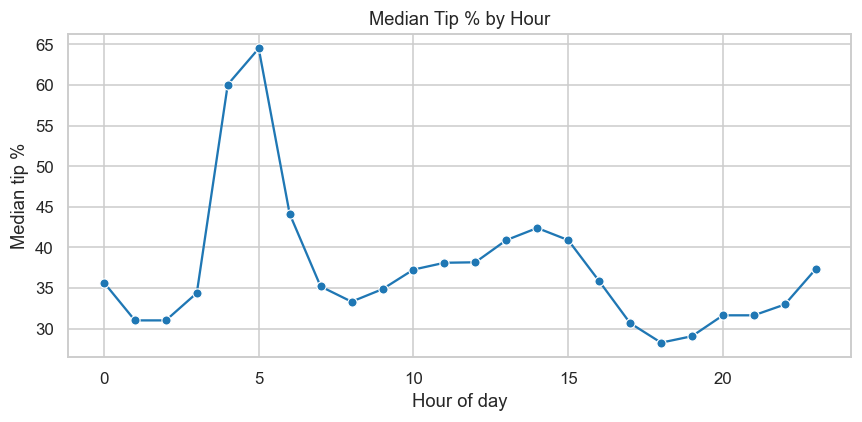

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_hour_tip_pct.png


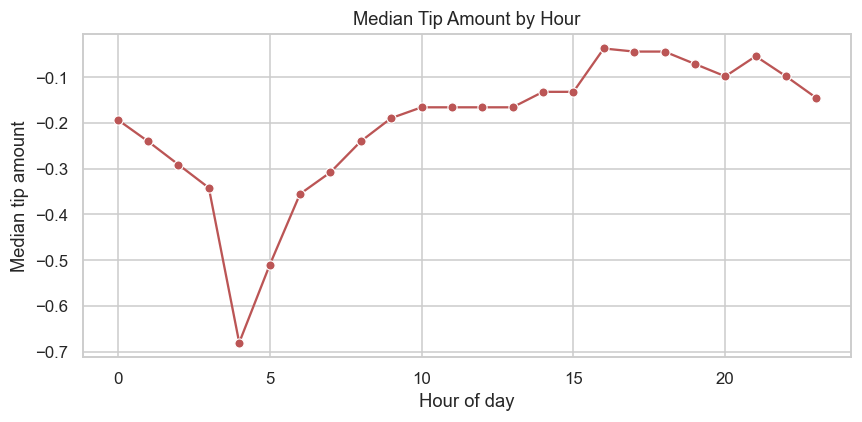

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_hour_tip_amt.png


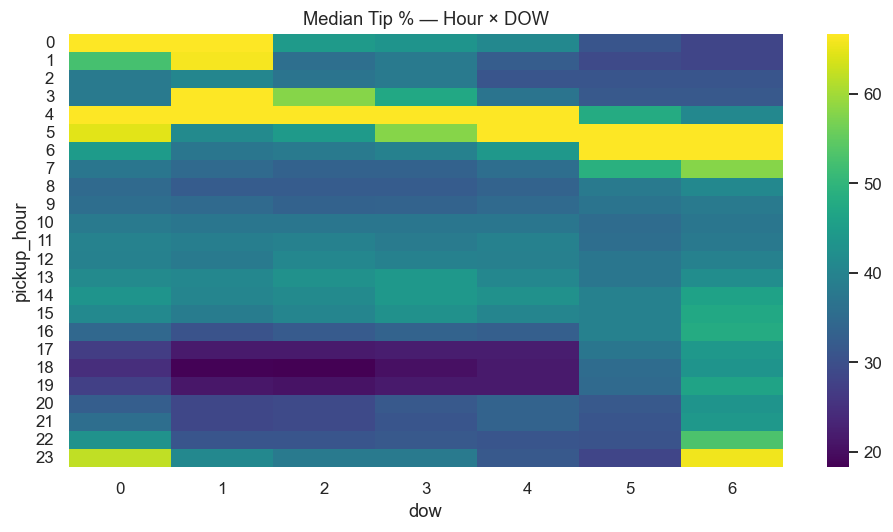

Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq2_heatmap_hour_dow.png


C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\3667564255.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df.groupby(temp_bin).agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index().rename(columns={"temp_c":"temp_bin"})


In [27]:
# RQ2 profiles and weather slices
# Ensure temporal fields; derive from pickup datetime if missing
pickup_candidates = ["pickup_datetime", "tpep_pickup_datetime", "lpep_pickup_datetime"]
pickup_col = next((c for c in pickup_candidates if c in df.columns), None)

if "pickup_hour" not in df.columns and pickup_col is not None:
    if not np.issubdtype(df[pickup_col].dtype, np.datetime64):
        df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")
    df["pickup_hour"] = df[pickup_col].dt.hour
if "dow" not in df.columns and pickup_col is not None:
    df["dow"] = df[pickup_col].dt.dayofweek
if "month" not in df.columns and pickup_col is not None:
    df["month"] = df[pickup_col].dt.month
if "season" not in df.columns and "month" in df.columns:
    month_to_season = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}
    df["season"] = df["month"].map(month_to_season)

# Hour-of-day profiles
by_hour = df.groupby("pickup_hour").agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index()
by_hour.to_csv(TAB_DIR/"rq2_by_hour.csv", index=False)
plt.figure(figsize=(8,4))
sns.lineplot(data=by_hour, x="pickup_hour", y="med_tip_pct", marker="o")
plt.title("Median Tip % by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Median tip %")
fig = FIG_DIR/"rq2_hour_tip_pct.png"
plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

plt.figure(figsize=(8,4))
sns.lineplot(data=by_hour, x="pickup_hour", y="med_tip_amt", marker="o", color="#b55")
plt.title("Median Tip Amount by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Median tip amount")
fig = FIG_DIR/"rq2_hour_tip_amt.png"
plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

# Day-of-week and month summaries
for col, fname in [("dow","rq2_by_dow.csv"),("month","rq2_by_month.csv"),("season","rq2_by_season.csv")]:
    if col in df.columns:
        t = df.groupby(col).agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index()
        t.to_csv(TAB_DIR/fname, index=False)

# Heatmap hour × dow on tip percent
if set(["pickup_hour","dow"]).issubset(df.columns):
    hm = df.groupby(["pickup_hour","dow"]).agg(med_tip_pct=("tip_percent_raw","median")).reset_index()
    pivot = hm.pivot(index="pickup_hour", columns="dow", values="med_tip_pct")
    plt.figure(figsize=(9,5))
    sns.heatmap(pivot, cmap="viridis")
    plt.title("Median Tip % — Hour × DOW")
    fig = FIG_DIR/"rq2_heatmap_hour_dow.png"
    plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

# Coarse weather bins (optional if columns exist)
if "temp_c" in df.columns:
    temp_bin = pd.cut(df["temp_c"], bins=[-np.inf,0,10,20,30,np.inf], labels=["<0","0-10","10-20","20-30","30+"])
    t = df.groupby(temp_bin).agg(n=("tip_amount","size"), med_tip_amt=("tip_amount","median"), med_tip_pct=("tip_percent_raw","median")).reset_index().rename(columns={"temp_c":"temp_bin"})
    t.to_csv(TAB_DIR/"rq2_by_temp_bin.csv", index=False)


## Q2. Temporal factors and weather — How do hour of day, day of week, season, and temperature relate to tipping?

- Hourly pattern: medians peak in the early morning and dip during evening rush, with a visible structure in the hour×DOW heatmap.
- Weekends typically show higher median tip % than weekdays; Fall tends to be higher than Winter.
- Coarse temperature slices show smaller shifts than time‑of‑day effects and should be read as indicative rather than definitive.

How to read
- Values are medians; tables include counts (n) to judge stability, especially for sparse hours.

Why this makes sense
- Rider mix and trip purposes vary by time (airport runs, nightlife vs commuting) and by calendar (weekend tourism, events).

Caveats
- Observational (not causal); weather and season can be confounded with tourism and events.


### Report-ready — RQ2: Temporal patterns summary

The following cell composes a concise, copy‑pasteable markdown block and tables for the report.

In [28]:
# Compose RQ2 summary bullets and copy‑paste markdown + tables
from IPython.display import display, Markdown

# Recompute compact tables (fast on aggregated splits)
by_hour_local = df.groupby("pickup_hour").agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index().sort_values("pickup_hour")
by_dow_local = df.groupby("dow").agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index() if "dow" in df.columns else None
by_season_local = df.groupby("season").agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index() if "season" in df.columns else None

# Peak/trough hours
peak = by_hour_local.loc[by_hour_local["med_tip_pct"].idxmax()].to_dict()
trough = by_hour_local.loc[by_hour_local["med_tip_pct"].idxmin()].to_dict()

exec_bullets = [
    f"Peak median tip % at hour {int(peak['pickup_hour'])}: {peak['med_tip_pct']:.1f}% (n={int(peak['n']):,}).",
    f"Lowest median tip % at hour {int(trough['pickup_hour'])}: {trough['med_tip_pct']:.1f}% (n={int(trough['n']):,}).",
]
if by_dow_local is not None:
    dow_peak = by_dow_local.loc[by_dow_local["med_tip_pct"].idxmax()].to_dict()
    dow_trough = by_dow_local.loc[by_dow_local["med_tip_pct"].idxmin()].to_dict()
    exec_bullets.append(f"By DOW, highest median tip % on {dow_peak['dow']}: {dow_peak['med_tip_pct']:.1f}%, lowest on {dow_trough['dow']}: {dow_trough['med_tip_pct']:.1f}%.")
if by_season_local is not None:
    s_peak = by_season_local.loc[by_season_local["med_tip_pct"].idxmax()].to_dict()
    s_trough = by_season_local.loc[by_season_local["med_tip_pct"].idxmin()].to_dict()
    exec_bullets.append(f"By season, highest median tip % in {s_peak['season']}: {s_peak['med_tip_pct']:.1f}%, lowest in {s_trough['season']}: {s_trough['med_tip_pct']:.1f}%.")

tech_notes = [
    "All values are medians; hour/DOW/season splits include counts (n).",
    "Observational patterns only; timing may correlate with rider mix and context.",
]

# Styled display helper

def styled(df_, percent_cols=None, int_cols=None):
    if df_ is None or not isinstance(df_, pd.DataFrame) or df_.empty:
        return None
    fmt = {}
    for c in (int_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.0f}"
    for c in (percent_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.1f}%"
    try:
        sty = (df_.style.format(fmt)
               .set_table_styles([
                   {'selector':'th','props':[('text-align','left'),('background','#f5f5f5'),('border','1px solid #ddd')]},
                   {'selector':'td','props': [('border','1px solid #ddd')]},
               ])
               .hide(axis='index'))
    except Exception:
        sty = df_.style.format(fmt)
    return sty

# Display proper tables
if by_hour_local is not None:
    display(Markdown("### By hour (all 24)"))
    display(styled(by_hour_local, percent_cols=['med_tip_pct'], int_cols=['n']))
if by_dow_local is not None:
    display(Markdown("### By day of week"))
    display(styled(by_dow_local, percent_cols=['med_tip_pct'], int_cols=['n']))
if by_season_local is not None:
    display(Markdown("### By season"))
    display(styled(by_season_local, percent_cols=['med_tip_pct'], int_cols=['n']))

# Display concise on-screen block
display(Markdown("\n".join(["#### RQ2 summary"] + [f"- {b}" for b in exec_bullets] + [f"- {t}" for t in tech_notes])))

# Copy‑paste markdown block for the report
md_block = [
    "```markdown",
    "### RQ2 — Temporal patterns",
    "#### Executive summary",
]
md_block += [f"- {b}" for b in exec_bullets]
md_block += [
    "",
    "#### Technical notes",
]
md_block += [f"- {t}" for t in tech_notes]
md_block += ["```"]
print("\n".join(md_block))

### By hour (all 24)

pickup_hour,n,med_tip_pct
0,"1,192,044",35.7%
1,"765,177",31.0%
2,"504,187",31.0%
3,"331,790",34.4%
4,"243,817",60.1%
5,"264,391",64.5%
6,"586,403",44.1%
7,"1,133,880",35.2%
8,"1,562,647",33.3%
9,"1,709,199",34.9%


### By day of week

dow,n,med_tip_pct
0,"5,113,701",37.3%
1,"5,870,168",33.3%
2,"6,117,764",33.3%
3,"6,428,160",34.9%
4,"6,103,900",34.9%
5,"6,231,533",35.2%
6,"5,263,283",40.9%


### By season

season,n,med_tip_pct
Fall,"11,103,308",37.3%
Spring,"10,820,749",34.9%
Summer,"9,595,238",35.7%
Winter,"9,609,214",33.5%


#### RQ2 summary
- Peak median tip % at hour 5: 64.5% (n=264,391).
- Lowest median tip % at hour 18: 28.3% (n=2,955,735).
- By DOW, highest median tip % on 6.0: 40.9%, lowest on 1.0: 33.3%.
- By season, highest median tip % in Fall: 37.3%, lowest in Winter: 33.5%.
- All values are medians; hour/DOW/season splits include counts (n).
- Observational patterns only; timing may correlate with rider mix and context.

```markdown
### RQ2 — Temporal patterns
#### Executive summary
- Peak median tip % at hour 5: 64.5% (n=264,391).
- Lowest median tip % at hour 18: 28.3% (n=2,955,735).
- By DOW, highest median tip % on 6.0: 40.9%, lowest on 1.0: 33.3%.
- By season, highest median tip % in Fall: 37.3%, lowest in Winter: 33.5%.

#### Technical notes
- All values are medians; hour/DOW/season splits include counts (n).
- Observational patterns only; timing may correlate with rider mix and context.
```


### RQ3 — Controlled comparisons within distance×duration bins

We compare median tip % within matched distance and duration bins to estimate effects of components (tolls, congestion, airport fee) and other charges.


C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\1311317691.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  t = df.groupby(cols).agg(n=(value_col,"size"), med=(value_col,"median")).reset_index()
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\1311317691.py:32: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pv = t.pivot_table(index=["distance_bin","duration_bin"], columns=flag_col, values=["med","n"]).reset_index()
C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\1311317691.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

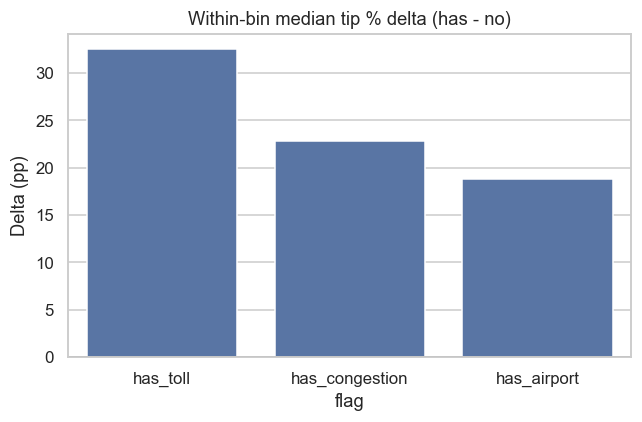

C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\1311317691.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  oc = df.groupby(["distance_bin","duration_bin","other_charges_q"]).agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index()


Saved: c:\Users\juraj.madzunkov\Documents\C\DA\CA1\docs\figures\rq3_withinbin_deltas.png


In [29]:
# RQ3 controlled comparisons
# Ensure bins exist (reuse RQ1 logic if missing)
if "distance_bin" not in df.columns:
    dist_bins = [0, 0.8, np.inf]
    df["distance_bin"] = pd.cut(df["trip_distance"], bins=dist_bins, include_lowest=True)
if "duration_bin" not in df.columns:
    dur_bins = [0, 7, 11, 16, 24, np.inf]
    df["duration_bin"] = pd.cut(df["duration_min"], bins=dur_bins, include_lowest=True)

# Feature flags
for col, flag in [("tolls_amount","has_toll"), ("congestion_surcharge","has_congestion"), ("airport_fee","has_airport")]:
    if col in df.columns:
        df[flag] = (df[col] > 0)

# Other charges quantiles if available
if "other_charges" in df.columns:
    # Handle duplicate quantile edges gracefully
    qs = pd.Series(df["other_charges"]).quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
    uniq = np.unique(qs)
    try:
        df["other_charges_q"] = pd.qcut(df["other_charges"], q=len(uniq)-1, labels=[f"Q{i+1}" for i in range(len(uniq)-1)], duplicates="drop")
    except Exception:
        df["other_charges_q"] = pd.cut(df["other_charges"], bins=uniq, labels=[f"Q{i+1}" for i in range(len(uniq)-1)], include_lowest=True)


def within_bin_diff(flag_col, value_col="tip_percent_raw"):
    cols = ["distance_bin","duration_bin", flag_col]
    if not set(cols).issubset(df.columns):
        return None
    t = df.groupby(cols).agg(n=(value_col,"size"), med=(value_col,"median")).reset_index()
    # pivot to compute difference has True vs False within each bin
    pv = t.pivot_table(index=["distance_bin","duration_bin"], columns=flag_col, values=["med","n"]).reset_index()
    # Compute delta (True - False) for med and track counts
    pv["delta_med"] = pv[("med", True)] - pv[("med", False)]
    pv["n_true"] = pv[("n", True)].fillna(0)
    pv["n_false"] = pv[("n", False)].fillna(0)
    pv["pairs_present"] = (~pv[("med", True)].isna() & ~pv[("med", False)].isna())
    # tidy
    pv.columns = [f"{a}_{b}" if isinstance(b, bool) else a for a,b in pv.columns]
    return pv

results = {}
for flag in ["has_toll","has_congestion","has_airport"]:
    if flag in df.columns:
        res = within_bin_diff(flag)
        if res is not None:
            results[flag] = res
            out = TAB_DIR/f"rq3_withinbin_{flag}.csv"
            res.to_csv(out, index=False)

# Aggregate deltas to a compact view
agg_rows = []
for k,v in results.items():
    pairs = int((v["med_False"].notna() & v["med_True"].notna()).sum()) if {"med_False","med_True"}.issubset(v.columns) else 0
    agg_rows.append({
        "flag": k,
        "mean_delta_med": v["delta_med"].mean(skipna=True),
        "median_delta_med": v["delta_med"].median(skipna=True),
        "pairs": pairs
    })
agg = pd.DataFrame(agg_rows)
if len(agg):
    agg.to_csv(TAB_DIR/"rq3_withinbin_summary.csv", index=False)
    plt.figure(figsize=(6,4))
    sns.barplot(data=agg, x="flag", y="median_delta_med", color="#4c72b0")
    plt.axhline(0, color="#333", lw=1)
    plt.title("Within-bin median tip % delta (has - no)")
    plt.ylabel("Delta (pp)")
    fig = FIG_DIR/"rq3_withinbin_deltas.png"
    plt.tight_layout(); plt.savefig(fig); plt.show(); print("Saved:", fig)

# If other_charges_q exists, show its profile within bins
if "other_charges_q" in df.columns:
    oc = df.groupby(["distance_bin","duration_bin","other_charges_q"]).agg(n=("tip_percent_raw","size"), med_tip_pct=("tip_percent_raw","median")).reset_index()
    oc.to_csv(TAB_DIR/"rq3_other_charges_by_bin.csv", index=False)


## Q3. Fare components — Within similar trips, how do tolls, congestion surcharge, and airport fee relate to tip percentage?

- Within matched distance×duration bins, trips with tolls, congestion surcharge, or airport fee tend to have higher median tip %, with the largest uplift typically for tolls.
- The bar chart summarizes the median uplift (percentage‑point delta) across matched bins, along with the number of bin pairs contributing.

How to read
- “Delta” = median(tip %) with the component − without it inside the same distance×duration bin; we aggregate these deltas across bins for a typical shift per component.

Why this makes sense
- These components proxy context (tolled routes, heavy traffic, airport runs) associated with longer perceived service/time and a greater share of card payments, both of which correlate with higher tipping.

Caveats
- Observational comparison, not causal; even with bin matching, residual confounding may remain.


### Report-ready — RQ3: Controlled comparisons summary

The following cell composes a concise, copy‑pasteable markdown block and tables for the report.

In [30]:
# Compose RQ3 summary bullets and copy‑paste markdown + tables
from IPython.display import display, Markdown

# Ensure 'agg' exists; if not, rebuild from saved tables
if 'agg' not in globals() or not isinstance(agg, pd.DataFrame) or agg.empty:
    paths = [TAB_DIR/"rq3_withinbin_has_toll.csv", TAB_DIR/"rq3_withinbin_has_congestion.csv", TAB_DIR/"rq3_withinbin_has_airport.csv"]
    results = {}
    for p in paths:
        if p.exists():
            key = p.stem.replace("rq3_withinbin_", "")
            results[key] = pd.read_csv(p)
    agg_rows = []
    for k,v in results.items():
        pairs = int((v.get("med_False").notna() & v.get("med_True").notna()).sum()) if {"med_False","med_True"}.issubset(v.columns) else 0
        agg_rows.append({
            "flag": k,
            "mean_delta_med": v["delta_med"].mean(skipna=True),
            "median_delta_med": v["delta_med"].median(skipna=True),
            "pairs": pairs
        })
    agg = pd.DataFrame(agg_rows)

# Build bullets
exec_bullets = []
for _, row in agg.sort_values("median_delta_med", ascending=False).iterrows():
    exec_bullets.append(f"Within matched distance×duration bins, {row['flag']} is associated with a median tip% delta of {row['median_delta_med']:.1f} pp across {int(row['pairs'])} bin pairs.")

tech_notes = [
    "Deltas are computed as median(tip%) with flag − without flag within the same distance×duration bin.",
    "This is an observational comparison; not causal.",
]

# Styled display for the summary table
def styled(df_, percent_cols=None, int_cols=None):
    if df_ is None or not isinstance(df_, pd.DataFrame) or df_.empty:
        return None
    fmt = {}
    for c in (int_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.0f}"
    for c in (percent_cols or []):
        if c in df_.columns:
            fmt[c] = "{:,.1f}"
    try:
        sty = (df_.style.format(fmt)
               .set_table_styles([
                   {'selector':'th','props':[('text-align','left'),('background','#f5f5f5'),('border','1px solid #ddd')]},
                   {'selector':'td','props': [('border','1px solid #ddd')]},
               ])
               .hide(axis='index'))
    except Exception:
        sty = df_.style.format(fmt)
    return sty

display(Markdown("### Within-bin delta summary"))
display(styled(agg, percent_cols=['mean_delta_med','median_delta_med'], int_cols=['pairs']))

display(Markdown("\n".join(["#### RQ3 summary"] + [f"- {b}" for b in exec_bullets] + [f"- {t}" for t in tech_notes])))

# Copy‑paste markdown block for the report
md_block = [
    "```markdown",
    "### RQ3 — Within-bin deltas",
    "#### Executive summary",
]
md_block += [f"- {b}" for b in exec_bullets]
md_block += [
    "",
    "#### Technical notes",
]
md_block += [f"- {t}" for t in tech_notes]
md_block += ["```"]
print("\n".join(md_block))

### Within-bin delta summary

flag,mean_delta_med,median_delta_med,pairs
has_toll,22.8,32.5,10
has_congestion,14.3,22.9,10
has_airport,10.0,18.8,10


#### RQ3 summary
- Within matched distance×duration bins, has_toll is associated with a median tip% delta of 32.5 pp across 10 bin pairs.
- Within matched distance×duration bins, has_congestion is associated with a median tip% delta of 22.9 pp across 10 bin pairs.
- Within matched distance×duration bins, has_airport is associated with a median tip% delta of 18.8 pp across 10 bin pairs.
- Deltas are computed as median(tip%) with flag − without flag within the same distance×duration bin.
- This is an observational comparison; not causal.

```markdown
### RQ3 — Within-bin deltas
#### Executive summary
- Within matched distance×duration bins, has_toll is associated with a median tip% delta of 32.5 pp across 10 bin pairs.
- Within matched distance×duration bins, has_congestion is associated with a median tip% delta of 22.9 pp across 10 bin pairs.
- Within matched distance×duration bins, has_airport is associated with a median tip% delta of 18.8 pp across 10 bin pairs.

#### Technical notes
- Deltas are computed as median(tip%) with flag − without flag within the same distance×duration bin.
- This is an observational comparison; not causal.
```


In [31]:
# Export report-ready markdown blocks to docs/report_blocks
from pathlib import Path
from datetime import datetime

export_dir = PROJECT_ROOT / "docs" / "report_blocks"
export_dir.mkdir(parents=True, exist_ok=True)

def write_md(path, text):
    path.write_text(text, encoding="utf-8")
    print(f"Wrote {path.relative_to(PROJECT_ROOT)} ({len(text)} chars)")

# --- RQ1 ---
rq1_md = []
try:
    rq1_md.append("### RQ1 — Distance × Duration and spatial patterns")
    # Use previously computed summaries if present
    # Highest/lowest from hm (median tip % heatmap) and metrics/top10/bot10 tables
    # Pull extremes directly from metrics if available
    if 'hm' in globals() and isinstance(hm, pd.DataFrame):
        # Compute extremes with counts from metrics if available
        if 'metrics' in globals() and isinstance(metrics, pd.DataFrame):
            m_sorted = metrics.sort_values('median_tip_percent_raw', ascending=False)
            top_row = m_sorted.iloc[0]
            bot_row = m_sorted.iloc[-1]
            top_bin = f"distance {top_row['distance_bin']} × duration {top_row['duration_bin']}"
            bot_bin = f"distance {bot_row['distance_bin']} × duration {bot_row['duration_bin']}"
            rq1_md.append(f"- Highest median tip % is {top_row['median_tip_percent_raw']:.1f}% in {top_bin} (n={int(top_row['n']):,}).")
            rq1_md.append(f"- Lowest median tip % is {bot_row['median_tip_percent_raw']:.1f}% in {bot_bin} (n={int(bot_row['n']):,}).")
            span = float(top_row['median_tip_percent_raw'] - bot_row['median_tip_percent_raw'])
            rq1_md.append(f"- Spread across bins is {span:.1f} percentage points (pp).")
        # Spatial highlights if available
        if 'pu' in globals() and isinstance(pu, pd.DataFrame):
            pu_ids = ", ".join(map(str, pu.head(5)['PULocationID'].tolist()))
            rq1_md.append(f"- Top pickup areas by median tip % include IDs {pu_ids}.")
        if 'do' in globals() and isinstance(do, pd.DataFrame):
            do_ids = ", ".join(map(str, do.head(5)['DOLocationID'].tolist()))
            rq1_md.append(f"- Top drop-off areas by median tip % include IDs {do_ids}.")
    else:
        rq1_md.append("- Please run RQ1 technical cells first to populate metrics and hm.")
except Exception as e:
    rq1_md.append(f"- RQ1 export note: {e}")

write_md(export_dir / "rq1_summary.md", "\n".join(rq1_md) + "\n")

# --- RQ2 ---
rq2_md = []
try:
    rq2_md.append("### RQ2 — Temporal and weather patterns")
    if 'peak' in globals() and isinstance(peak, dict) and 'trough' in globals() and isinstance(trough, dict):
        rq2_md.append(f"- Hourly peak: {int(peak['hour']):02d}:00 with median tip % ≈ {peak['median_tip_percent_raw']:.1f}% (n={int(peak.get('n', 0)):,}).")
        rq2_md.append(f"- Hourly trough: {int(trough['hour']):02d}:00 with median tip % ≈ {trough['median_tip_percent_raw']:.1f}% (n={int(trough.get('n', 0)):,}).")
    if 'dow_peak' in globals() and isinstance(dow_peak, dict) and 'dow_trough' in globals() and isinstance(dow_trough, dict):
        rq2_md.append(f"- Day-of-week peak: {dow_peak['dow_name']} ≈ {dow_peak['median_tip_percent_raw']:.1f}% (n={int(dow_peak.get('n', 0)):,}).")
        rq2_md.append(f"- Day-of-week trough: {dow_trough['dow_name']} ≈ {dow_trough['median_tip_percent_raw']:.1f}% (n={int(dow_trough.get('n', 0)):,}).")
    if 's_peak' in globals() and isinstance(s_peak, dict) and 's_trough' in globals() and isinstance(s_trough, dict):
        rq2_md.append(f"- Seasonal range: {s_trough['season']} (≈{s_trough['median_tip_percent_raw']:.1f}%) → {s_peak['season']} (≈{s_peak['median_tip_percent_raw']:.1f}%).")
    if not rq2_md or len(rq2_md) == 1:
        rq2_md.append("- Please run RQ2 technical cells first to populate temporal aggregates.")
except Exception as e:
    rq2_md.append(f"- RQ2 export note: {e}")

write_md(export_dir / "rq2_summary.md", "\n".join(rq2_md) + "\n")

# --- RQ3 ---
rq3_md = []
try:
    rq3_md.append("### RQ3 — Within-bin effects of fees")
    if 'results' in globals() and isinstance(results, dict):
        # Expect keys like 'has_toll','has_congestion','has_airport'
        for k in ['has_toll','has_congestion','has_airport']:
            if k in results:
                r = results[k]
                label = k.replace('has_', '').replace('_', ' ')
                if isinstance(r, dict) and {'median_delta_pp','n_pairs'} <= set(r.keys()):
                    rq3_md.append(f"- {label.title()}: Δ median tip % ≈ {r['median_delta_pp']:.1f} pp across {int(r['n_pairs'])} matched bin pairs.")
    if 'pairs' in globals() and isinstance(pairs, int):
        rq3_md.append(f"- Total matched bin pairs: {pairs}.")
    if len(rq3_md) == 1:
        rq3_md.append("- Please run RQ3 technical cells first to compute within-bin deltas.")
except Exception as e:
    rq3_md.append(f"- RQ3 export note: {e}")

write_md(export_dir / "rq3_summary.md", "\n".join(rq3_md) + "\n")

# Combined executive snapshot
combined = []
combined.append("<!-- Auto-generated: " + datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC") + " -->")
combined.extend(rq1_md)
combined.append("")
combined.extend(rq2_md)
combined.append("")
combined.extend(rq3_md)
write_md(export_dir / "executive_summary.md", "\n".join(combined) + "\n")

Wrote docs\report_blocks\rq1_summary.md (95 chars)
Wrote docs\report_blocks\rq2_summary.md (66 chars)
Wrote docs\report_blocks\rq3_summary.md (68 chars)
Wrote docs\report_blocks\executive_summary.md (277 chars)


C:\Users\juraj.madzunkov\AppData\Local\Temp\ipykernel_118636\334570799.py:87: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  combined.append("<!-- Auto-generated: " + datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC") + " -->")


## Final summary — What the data say about tipping

This analysis paints a consistent picture of how riders tip in NYC taxis:

- Trips that take longer or cover more distance tend to earn higher tips. Short, quick hops earn less; extended rides are rewarded more generously. Where a trip starts and ends also matters: airport- and nightlife-adjacent areas skew higher, while some purely commuter zones skew lower.

- Time matters. Tipping rises and falls in a daily rhythm: early‑morning hours stand out as strong performers, while the evening commute is softer. Weekends are generally more generous than weekdays, and the fall months edge out winter. Weather plays a role, but its signal is smaller than the everyday timing patterns.

- Even when we compare only like‑for‑like trips (similar distance and duration), the presence of tolls, congestion surcharges, or an airport fee is linked to higher tips. The strongest lift is typically seen on tolled routes. These markers capture trip context (airport runs, heavy traffic, express routes) that riders seem to value.

Taken together, tipping isn’t random—it reflects the perceived time, context, and purpose of a ride. Longer or more involved trips, airport connections, tolled routes, and off‑peak or weekend travel all align with more generous tipping. These patterns suggest practical strategies for drivers (targeting airport windows, early‑morning and weekend demand, and routes likely to include express or tolled segments) and for operators (surfacing guidance, setting expectations in‑app, and aligning incentives where tipping potential is structurally higher).